Before  Binning

In [242]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [243]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.tree import DecisionTreeClassifier

In [244]:
df=pd.read_csv("data/Titanic-Dataset.csv")
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
227,228,0,3,"Lovell, Mr. John Hall (""Henry"")",male,20.5,0,0,A/5 21173,7.2500,NaN,S
299,300,1,1,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",female,50.0,0,1,PC 17558,247.5208,B58 B60,C
805,806,0,3,"Johansson, Mr. Karl Johan",male,31.0,0,0,347063,7.7750,NaN,S
722,723,0,2,"Gillespie, Mr. William Henry",male,34.0,0,0,12233,13.0000,NaN,S
591,592,1,1,"Stephenson, Mrs. Walter Bertram (Martha Eustis)",female,52.0,1,0,36947,78.2667,D20,C


In [245]:
df=pd.read_csv("data/Titanic-Dataset-Processed.csv",usecols=["Age","Fare","Survived"])
df.sample(5)

,Survived,Age,Fare
698,0,49.0,110.8833
753,0,23.0,7.8958
444,1,NaN,8.1125
425,0,NaN,7.2500
537,1,30.0,106.4250


In [246]:
df.dropna(inplace=True)

In [247]:
df.isna().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [248]:
x=df.drop(columns="Survived")
y=df["Survived"]

In [249]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [250]:
x_train.head(2)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542


In [251]:
lr=DecisionTreeClassifier()
lr.fit(x_train,y_train)
ypred=lr.predict(x_test)
accuracy_score(y_test,ypred)

0.6293706293706294

In [252]:
lr=DecisionTreeClassifier()
np.mean(cross_val_score(lr,x,y,scoring="accuracy"))

np.float64(0.6190584063823501)

After   binning

In [253]:
Bi=KBinsDiscretizer(n_bins=10,encode="ordinal",strategy="uniform")

x_train_trnf=Bi.fit_transform(x_train)
x_test_trnf=Bi.fit_transform(x_test)
# pd.DataFrame(x_train_trnf,columns="Age Lable")

In [254]:
lr=DecisionTreeClassifier()
lr.fit(x_train_trnf,y_train)
ypred2=lr.predict(x_test_trnf)
accuracy_score(y_test,ypred2)

0.6643356643356644

In [255]:
lr=DecisionTreeClassifier()
np.mean(cross_val_score(lr,x,y,scoring="accuracy"))

np.float64(0.6260514133753571)

In [256]:
object={
    "Age":x_train["Age"],
    "Age_label":x_train_trnf[:,0],
    "Fare":x_train["Fare"],
    "Fare_label":x_train_trnf[:,1],


}
object
dfnew=pd.DataFrame(object)
dfnew.sample(10)

,Age,Age_label,Fare,Fare_label
348,3.00,0.0,15.9000,0.0
627,21.00,2.0,77.9583,1.0
803,0.42,0.0,8.5167,0.0
558,39.00,4.0,79.6500,1.0
387,36.00,4.0,13.0000,0.0
623,21.00,2.0,7.8542,0.0
887,19.00,2.0,30.0000,0.0
600,24.00,2.0,27.0000,0.0
597,49.00,6.0,0.0000,0.0
208,16.00,1.0,7.7500,0.0


In [257]:
Bi=KBinsDiscretizer(n_bins=10,encode="ordinal",strategy="quantile")
x_train_trnf=Bi.fit_transform(x_train)
x_test_trnf=Bi.fit_transform(x_test)
lr=DecisionTreeClassifier()
lr.fit(x_train_trnf,y_train)
ypred2=lr.predict(x_test_trnf)
accuracy_score(y_test,ypred2)

c:\Users\ANIKET GUPTA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\ANIKET GUPTA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


0.6853146853146853

In [258]:
object={
    "Age":x_train["Age"],
    "Age_label":x_train_trnf[:,0],
    "Fare":x_train["Fare"],
    "Fare_label":x_train_trnf[:,1],


}
object
dfnew=pd.DataFrame(object)
dfnew.sample(10)

,Age,Age_label,Fare,Fare_label
231,29.0,5.0,7.7750,1.0
860,41.0,7.0,14.1083,4.0
530,2.0,0.0,26.0000,6.0
659,58.0,9.0,113.2750,9.0
806,39.0,7.0,0.0000,0.0
254,41.0,7.0,20.2125,5.0
583,36.0,7.0,40.1250,7.0
24,8.0,0.0,21.0750,5.0
574,16.0,1.0,8.0500,2.0
607,27.0,4.0,30.5000,7.0


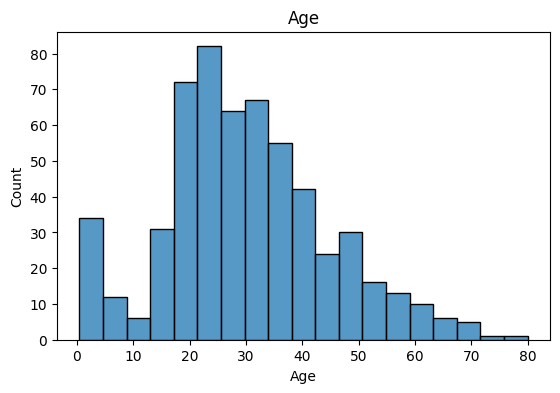

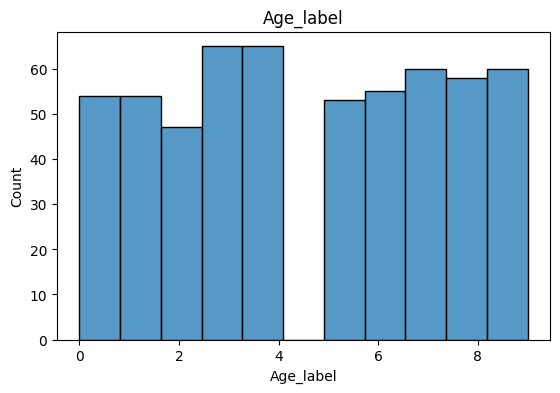

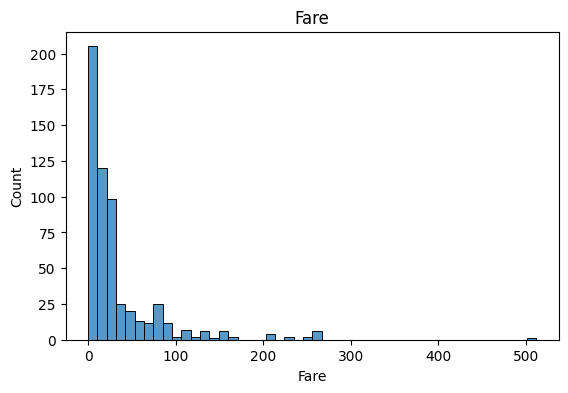

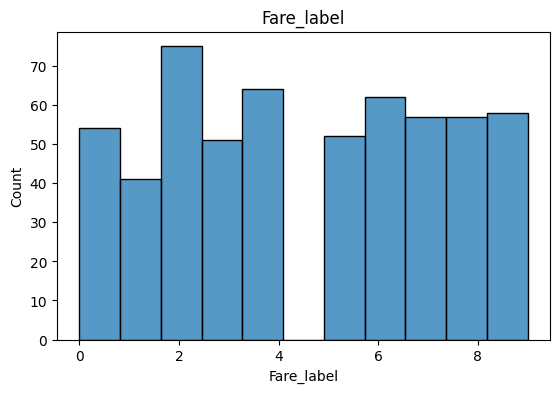

In [264]:
for col in dfnew.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(dfnew[col])
    plt.title(col)
    plt.show()




In [265]:
def binnig(bins,method):
    Bi=KBinsDiscretizer(n_bins=bins,encode="ordinal",strategy=method)
    x_train_trnf=Bi.fit_transform(x_train)
    x_test_trnf=Bi.fit_transform(x_test)
    lr=DecisionTreeClassifier()
    lr.fit(x_train_trnf,y_train)
    ypred2=lr.predict(x_test_trnf)
    accuracy_score(y_test,ypred2)
    object={
    "Age":x_train["Age"],
    "Age_label":x_train_trnf[:,0],
    "Fare":x_train["Fare"],
    "Fare_label":x_train_trnf[:,1],
    }
    object
    dfnew=pd.DataFrame(object)
    dfnew.sample(10)
    for col in dfnew.columns:
        plt.figure(figsize=(14,4))
        plt.subplot(121)
        sns.histplot(dfnew[col])
        plt.title(col)
        plt.show()


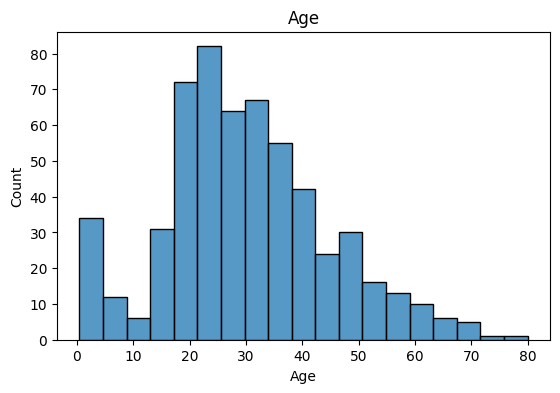

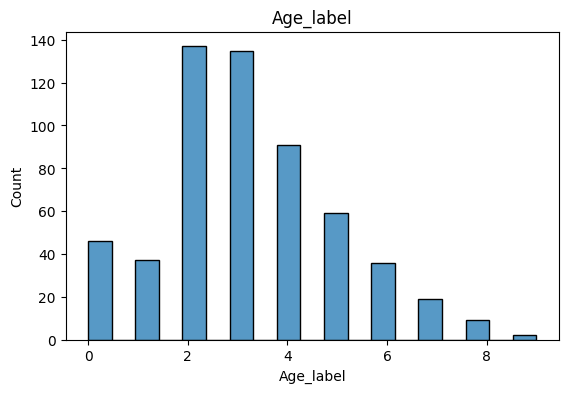

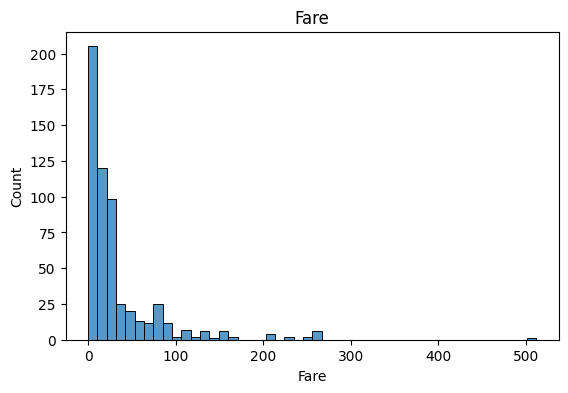

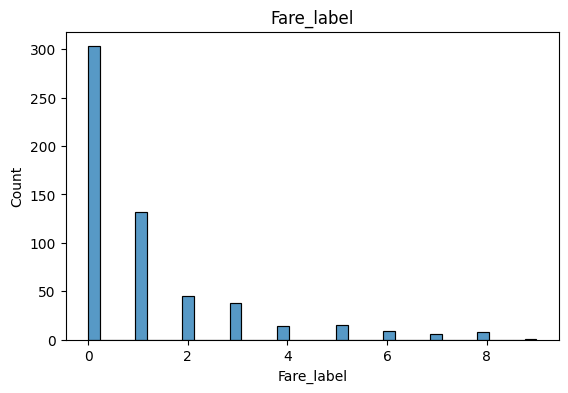

In [267]:
binnig(10,"kmeans")